In [2]:
import os
import numpy as np
import json
import glob
import random
import torch

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.figsize': [6,4]})

np.set_printoptions(precision=3)
np.set_printoptions(suppress=True)

# from agents.control_agents_deep import build_fc_net

In [3]:
# some helper functions used by all experiments

def build_fc_net(layer_sizes, activation=torch.nn.Tanh(), final_activation_layer=torch.nn.Identity(), ortho_init=False):
    """Returns a full-connected network with an argument-specified activation function."""
    assert len(layer_sizes) > 1
    layers = []
    for index in range(len(layer_sizes) - 1):
        linear = torch.nn.Linear(layer_sizes[index], layer_sizes[index + 1])
        if ortho_init:
            torch.nn.init.orthogonal_(linear.weight, 1)
            torch.nn.init.constant_(linear.bias, 0)
        act = activation if index < len(layer_sizes) - 2 else final_activation_layer
        layers += (linear, act)
    return torch.nn.Sequential(*layers)

def all_files_with_prefix_and_suffix(location, prefix, suffix):
    """returns a list of all files in the 'location' starting with the given prefix"""
    if location[-1] != '/':
        location += '/'
    files = glob.glob(location + prefix + '*' + suffix)

    return files


def plot_sensitivity(param_list, item, param2='alpha', title=None, firstn=-1, last_from=-1, 
                     num_sa=None, logbase=-1, ylabel='RMSVE\n(TVR)', y_lims=None,
                     out_location=None, final=False, param_choose_only=None):

    data_all = {}
    X, Y = [], []
    for location, filename_prefix, param1 in param_list:
    
        files = all_files_with_prefix_and_suffix(location, filename_prefix, '*.npy')
        assert len(files) > 0, 'No files found with the prefix: ' + location + filename_prefix
        print('Filename\t%s\t%s\tValue\n' % (param1, param2))
        for file in files:
            data = np.load(file, allow_pickle=True).item()
            param1_value = data['params'][param1]
            if data['params'][param_choose_only[0]] != param_choose_only[1]:
                continue
            if param1_value not in data_all:
                data_all[param1_value] = {}
                X.append(param1_value)
            param2_value = data['params'][param2]
            if param2_value not in data_all[param1_value]:
                data_all[param1_value][param2_value] = {}
                Y.append(param2_value)
            assert not (firstn!=-1 and last_from!=-1), "Both firstn and lastn can't be chosen together"
            if firstn != -1:
                data_to_eval = data[item][:,:firstn]
            elif last_from != -1:
                data_to_eval = data[item][:,last_from:]
            else:
                data_to_eval = data[item]
            metric_per_run = np.mean(data_to_eval, axis=1)
            metric = np.mean(metric_per_run)
            metric_stderr = np.std(metric_per_run) / np.sqrt(metric_per_run.size)
            data_all[param1_value][param2_value] = (metric, metric_stderr)
            print('%s\t%s\t%s\t%.3f\t%.3f' % (file[-10:-3], param1_value, param2_value, metric, metric_stderr))

    try: 
        X = sorted(set(X))
    except:
        print('Cannot sort; keys are a mix of numbers and letters')
        X = data_all.keys()
    Y = sorted(set(Y))
    Z_mean = np.zeros((len(X), len(Y)))
    Z_stderr = np.zeros((len(X), len(Y)))
    Z_attrs = ['']*len(X)
    # print(Z_attrs)
    for i, x in enumerate(X):
        for j, y in enumerate(Y):
            try:
                Z_mean[i][j] = data_all[x][y][0]
                Z_stderr[i][j] = data_all[x][y][1]
            except:
                Z_mean[i][j] = np.nan
                Z_stderr[i][j] = np.nan
        print(i, x)
#         if x=='max_all_sa':
#             Z_attrs[i] = 'dashed'
    Z_mean = np.ma.masked_invalid(Z_mean)
    Z_stderr = np.ma.masked_invalid(Z_stderr)

    fig, ax = plt.subplots(1, 1)#, figsize=(5.5,4))

    # colors = ['darkturquoise', 'magenta']
    # if param_choose_only[0] in ['gamma', 'eta']:
    #     print('Changing value_init/reward_rate_init to reward_offset')
    #     X = list(map((lambda x: x * -1), X))
    tick_positions = Y
    if param2=='gamma':
        tick_positions = list(range(len(Y)))
    for i, param_value in enumerate(X):
        ax.errorbar(tick_positions, Z_mean[i], yerr=Z_stderr[i], label=str(param_value))#, linestyle=Z_attrs[i])#, color=colors[i])
    if final!=True:
        ax.legend()
        plt.xlabel(param2)
        plt.ylabel(ylabel, rotation=0, labelpad=40)
        ax.set_title(title)
    if y_lims != None:            # typically (0.21, 0.39) for TC, (2.05, 2.6) for AC, (0, 0.9) for Catcher
        plt.ylim(y_lims[0], y_lims[1])
    ax.grid(visible=True, axis='y', alpha=0.5, linestyle='--')
    if logbase != -1:
        assert param2 != 'gamma', 'do not use log scale with gamma'
        ax.set_xscale("log", base=logbase)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(Y)
    fig.tight_layout()
    if final==True:
        assert os.path.isfile(out_location + title + '.png') == False, "File already exists. Don't overwrite!"
        plt.savefig(out_location + title + '.png', dpi=1200, transparent=True)
    plt.show()


def plot_learning_curve(files, item='reward', window=1000, sample=1, firstn=-1,
                        title=None, h_line=None, ylims=None, plot_all_runs=False,
                        print_final_reward_rate=False, print_max_value_over_last_tenth=False,
                        out_location=None, final=False, file_title=None, labels=None):

    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    # colors = ['blue', 'orange', '#37f24a', '#2cbd3d', '#208c2b', '#f24235', '#bd332a', '#8f2822']
    fig, ax = plt.subplots(1, 1, figsize=(6,4))
    which_step_size = 'alpha_w'
    for i, (location, filename, label) in enumerate(files):
        data = np.load(location + filename, allow_pickle=True).item()
        rewards_train = data[item][:,:firstn]
#         if data['params']['robust_to_initialization']:
#             rewards_train -= data['params']['reward_offset']
        max_run_length = rewards_train.shape[1]
        if print_final_reward_rate:
            idx = int(data["avgrew"].shape[1] * 0.1)
#             print(f'Over {data["params"]["num_runs"]} runs: {np.mean(data["avgrew"][:,-10:])} +- {np.std(data["avgrew"][:,-10:])}')
            print(f'Learned reward rate (final): {np.mean(data["avgrew_final"]):.3f}')
            print(f'Learned reward rate over last 10%: {np.mean(data["avgrew"][:,-idx:]):.3f}')
        if print_max_value_over_last_tenth:
            print(f'Max value over the last 10% steps: {np.nanmean(data["max_value_per_step"])}\n')
        conv_arr = np.ones(window)
        reward_rate_all = []
        x_s = np.arange(window, max_run_length+1)[::sample] #* data['params']['eval_every_n_steps']
        # ToDo: vectorize this
        for run in range(rewards_train.shape[0]):
            reward_rate = np.convolve(rewards_train[run,:], conv_arr, mode='valid') / window
            reward_rate_all.append(reward_rate)
            if plot_all_runs:
                plt.plot(x_s, reward_rate, alpha=0.1, color=colors[i % len(colors)])
        reward_rate_all = np.array(reward_rate_all)
        mean = np.mean(reward_rate_all, axis=0)
        stderr = np.std(reward_rate_all, axis=0) / np.sqrt(reward_rate_all.shape[0])
        y_s = mean[::sample]
        stderr_s = stderr[::sample]
        if label == "":
            label = ', '.join([f"{label}={data['params'][label]}" for label in labels.split(',')]) 
        plt.plot(x_s, y_s, label=label, color=colors[i % len(colors)])
        plt.fill_between(x_s, y_s + stderr_s, y_s - stderr_s, alpha=0.3, color=colors[i % len(colors)])

    if h_line!= None:
        plt.axhline(y=h_line, color='black', alpha=0.3, linestyle='--')
    plt.grid(visible=True, axis='y', alpha=0.5, linestyle='--')
    if ylims != None:
        plt.ylim(ylims[0], ylims[1])
    if not final:
        plt.legend()
        plt.title(title)
#         plt.xlabel('Time steps')
#         plt.ylabel('RMSVE\n(TVR)', rotation=0, labelpad=40)
    plt.tight_layout()
    if final:
        assert os.path.isfile(out_location + file_title + '.png') == False, "File already exists. Don't overwrite!"
        plt.savefig(out_location + file_title + '.png', dpi=1200, transparent=True)
    plt.show()
    
def print_config(filename):

    data = np.load(filename, allow_pickle=True).item()
    params = data['params']
    print(params)


def visualize_value_fn_pen(results_folder, npy_log_file, run_idx=0, critic_state_only=False, norm_obs=False):
    data = np.load(results_folder + npy_log_file, allow_pickle=True).item()
    params = data['params']
#     model_filename_root = f'{results_folder}models/{npy_log_file[:-4]}/{npy_log_file[:-4]}_{run_idx}_'
    model_filename_root = f'{results_folder}models/{npy_log_file[:-4]}_{run_idx}_'
    critic = build_fc_net(params['critic_arch'], activation=torch.nn.ReLU())
    if 'SAC' in npy_log_file:
        critic.load_state_dict(torch.load(model_filename_root + 'critic0.pth', weights_only=True))
    else:
        critic.load_state_dict(torch.load(model_filename_root + 'critic.pth', weights_only=True))
    actor = build_fc_net(params['actor_arch'], activation=torch.nn.ReLU(), final_activation_layer=torch.nn.Tanh())
    actor.load_state_dict(torch.load(model_filename_root + 'actor.pth', weights_only=True))

    if norm_obs:
        obs_mean = data['misc'][run_idx]['obs_mean']
        obs_std = data['misc'][run_idx]['obs_std']
        print(f'Observation mean and std: {obs_mean}, {obs_std}')
    
    thetas = np.arange(0, 6.3, 0.1)
    theta_dots = np.arange(-6, 6, 0.1)
#     thetas_centered = ((thetas + 1.2)/1.8 - 0.5) * 2 
#     theta_dots_centered = ((theta_dots + 0.07)/0.14 - 0.5) * 2

    states = np.zeros((thetas.shape[0] * theta_dots.shape[0], 3), dtype=np.float32)
    for i in range(thetas.shape[0]):
        for j in range(theta_dots.shape[0]):
            states[i*theta_dots.shape[0] + j] = (np.array([np.cos(thetas[i]), np.sin(thetas[i]), 
                                                          theta_dots[j]], dtype=np.float32) - obs_mean) / obs_std 
    
    with torch.no_grad():
        states = torch.from_numpy(states)
        actions = actor(states)[:,:params['num_actions']]
        if critic_state_only:
            values = critic(states)
        else:
            values = critic(torch.cat([states, actions], dim=1))

#     for i in range(thetas.shape[0]):
#         for j in range(theta_dots.shape[0]):
#             print(thetas[i], theta_dots[j], values[i*theta_dots.shape[0] + j])
        
    fig, ax = plt.subplots(1,1)#, figsize=(10,10))
    plt.imshow(values.reshape((63, 120)).t(), aspect='auto')
    ax.set_xticks(np.arange(63)[::10], [f'{p:.1f}' for p in thetas[::10]])
    ax.set_yticks(np.arange(120)[::20], [f'{v:.1f}' for v in theta_dots[::20]])
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel(r'$\dot{\theta}$', rotation=0, labelpad=30)
    plt.colorbar()

def visualize_PW(results_folder, npy_log_file, run_idx=0, goal_xs=[4.8], critic_state_only=False, norm_obs=False):
    data = np.load(results_folder + npy_log_file, allow_pickle=True).item()
    params = data['params']
#     model_filename_root = f'{results_folder}models/{npy_log_file[:-4]}/{npy_log_file[:-4]}_{run_idx}_'
    model_filename_root = f'{results_folder}models/{npy_log_file[:-4]}_{run_idx}_'
    critic = build_fc_net(params['critic_arch'], activation=torch.nn.ReLU())
    if 'SAC' in npy_log_file:
        critic.load_state_dict(torch.load(model_filename_root + 'critic0.pth', weights_only=True))    
    else:
        critic.load_state_dict(torch.load(model_filename_root + 'critic.pth', weights_only=True))
    actor = build_fc_net(params['actor_arch'], activation=torch.nn.ReLU(), final_activation_layer=torch.nn.Tanh())
    actor.load_state_dict(torch.load(model_filename_root + 'actor.pth', weights_only=True))
    if norm_obs:
        obs_mean = data['misc'][run_idx]['obs_mean']
        obs_std = data['misc'][run_idx]['obs_std']
        print(f'Observation mean and std: {obs_mean}, {obs_std}')
    
    x_granularity = 0.1
    
    xs = np.arange(0, 5, x_granularity)
    ys = np.arange(0, 1, 1)

    for goal_x in goal_xs:
    
        states = np.zeros((xs.shape[0] * ys.shape[0], 3), dtype=np.float32)
        for i in range(xs.shape[0]):
            for j in range(ys.shape[0]):
                states[i*ys.shape[0] + j] = (np.array([xs[i], 0, goal_x], dtype=np.float32) - obs_mean) / obs_std 

        # states = (states - obs_mean) / obs_std
        
        with torch.no_grad():
            states = torch.from_numpy(states)
            actions = actor(states)[:,:params['num_actions']]
            if critic_state_only:
                values = critic(states)
            else:
                test_actions = torch.zeros_like(actions)
                values = critic(torch.cat([states, test_actions], dim=1))

    #     for i in range(thetas.shape[0]):
    #         for j in range(theta_dots.shape[0]):
    #             print(thetas[i], theta_dots[j], values[i*theta_dots.shape[0] + j])

        fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,2))
#         fig.suptitle(f'Goal_x = {goal_x}\n\n', x=0.43, y=1.2)

        # visualize the policy
        im1 = ax1.imshow(actions.reshape((50, 1)).t(), aspect='auto')
        ax1.set_xticks([])
        ax1.set_yticks(np.arange(1), [f'{v:.1f}' for v in ys])
        ax1.set_ylabel('y', rotation=0, labelpad=10)
        ax1.scatter(x=goal_x / x_granularity, y=0, color='red')
        ax1.set_title('Policy')
        fig.colorbar(im1, ax=ax1, aspect=2)

        # visualize the value function
        im2 = ax2.imshow(values.reshape((50, 1)).t(), aspect='auto')
        ax2.set_xticks(np.arange(50)[::10], [f'{p:.1f}' for p in xs[::10]])
        ax2.set_yticks(np.arange(1), [f'{v:.1f}' for v in ys])
        ax2.set_xlabel('x')
        ax2.set_ylabel('y', rotation=0, labelpad=10)
        ax2.scatter(x=goal_x / x_granularity, y=0, color='red')
        ax2.set_title('Values')
        fig.colorbar(im2, ax=ax2, aspect=2)

        plt.subplots_adjust(hspace=1)


## PuckWorld 1D

## Sweep 1

### DDPG

Filename	eta	gamma	Value

DPG_14.	1.0	1	-0.901	0.052
DPG_15.	4.0	1	-0.955	0.082
DDPG_6.	1.0	0.99	-0.890	0.061
DPG_12.	0.0	1	-1.048	0.102
DPG_10.	1.0	0.999	-0.856	0.054
DDPG_4.	0.0	0.99	-0.937	0.057
DPG_11.	4.0	0.999	-0.948	0.076
DDPG_5.	0.4	0.99	-0.928	0.073
DPG_13.	0.4	1	-0.945	0.079
DDPG_9.	0.4	0.999	-1.015	0.101
DDPG_7.	4.0	0.99	-0.981	0.083
DDPG_8.	0.0	0.999	-0.948	0.083
DDPG_0.	0.0	0.9	-0.860	0.065
DDPG_3.	4.0	0.9	-0.956	0.092
DDPG_1.	0.4	0.9	-0.869	0.056
DDPG_2.	1.0	0.9	-0.859	0.059
0 0.0
1 0.4
2 1.0
3 4.0


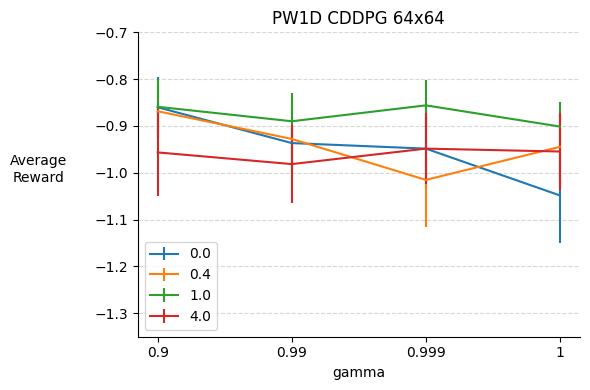

In [7]:
param_list = [('../results/centering_sweep/puckworld_1D/', 'puckworld1D_cont_CDiscDDPG', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.7), #firstn=400, #logbase=10, 
                 title=r'PW1D CDDPG 64x64', final=False)

/tmp/ipykernel_910233/44550407.py:166: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/gpfs/work/naika/venvs/dev/lib64/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


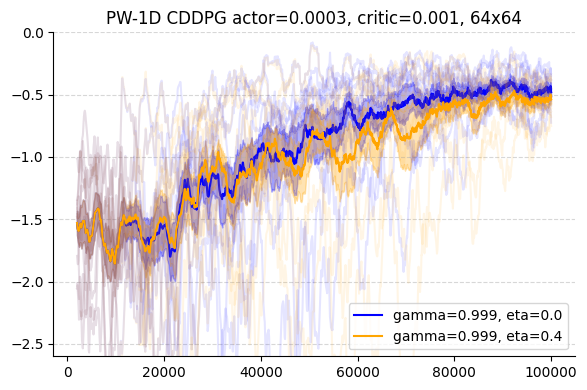

In [4]:
filenames = [('../results/centering_sweep/puckworld_1D/', 'puckworld1D_cont_CDiscDDPG_8.npy'),
             ('../results/centering_sweep/puckworld_1D/', 'puckworld1D_cont_CDiscDDPG_9.npy'),
            ]    

plot_learning_curve(filenames, item='reward', window=2000, ylims=(-2.6, 0),
                    title=r'PW-1D CDDPG actor=0.0003, critic=0.001, 64x64', final=False, plot_all_runs=True, labels='gamma,eta')

### TD3

Filename	eta	gamma	Value

TD3_14.	1.0	1.0	-1.208	0.101
cTD3_3.	4.0	0.9	-1.235	0.128
cTD3_2.	1.0	0.9	-1.212	0.130
cTD3_8.	0.0	0.999	-1.184	0.126
cTD3_5.	0.4	0.99	-1.225	0.100
cTD3_0.	0.0	0.9	-1.230	0.126
cTD3_7.	4.0	0.99	-1.160	0.122
TD3_13.	0.4	1.0	-1.114	0.085
cTD3_4.	0.0	0.99	-1.176	0.106
TD3_11.	4.0	0.999	-1.204	0.114
TD3_15.	4.0	1.0	-1.164	0.108
cTD3_9.	0.4	0.999	-1.238	0.115
cTD3_6.	1.0	0.99	-1.251	0.119
TD3_12.	0.0	1.0	-1.173	0.119
TD3_10.	1.0	0.999	-1.237	0.109
cTD3_1.	0.4	0.9	-1.248	0.126
0 0.0
1 0.4
2 1.0
3 4.0


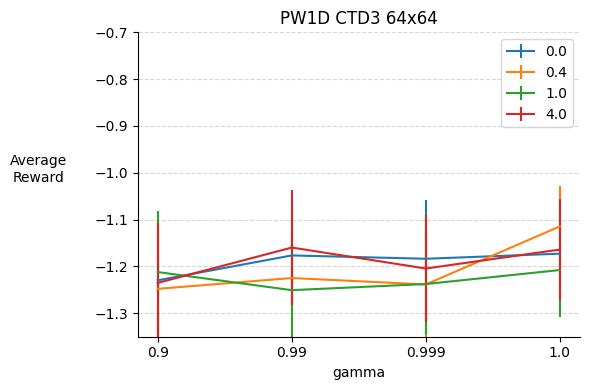

In [8]:
param_list = [('../results/centering_sweep/puckworld_1D/', 'puckworld1D_cont_CDiscTD3', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.7), #firstn=400, #logbase=10, 
                 title=r'PW1D CTD3 64x64', final=False)

### SAC

Filename	eta	gamma	Value

SAC_15.	4.0	1.0	-1.114	0.078
cSAC_0.	0.0	0.9	-0.928	0.034
cSAC_1.	0.4	0.9	-0.957	0.056
SAC_12.	0.0	1.0	-0.956	0.037
SAC_11.	4.0	0.999	-1.064	0.084
cSAC_6.	1.0	0.99	-0.986	0.046
SAC_14.	1.0	1.0	-0.991	0.045
cSAC_4.	0.0	0.99	-0.955	0.049
cSAC_8.	0.0	0.999	-0.966	0.056
cSAC_9.	0.4	0.999	-0.953	0.035
SAC_13.	0.4	1.0	-0.964	0.050
cSAC_7.	4.0	0.99	-1.080	0.072
cSAC_2.	1.0	0.9	-0.963	0.044
cSAC_5.	0.4	0.99	-0.938	0.038
SAC_10.	1.0	0.999	-0.955	0.048
cSAC_3.	4.0	0.9	-0.927	0.040
0 0.0
1 0.4
2 1.0
3 4.0


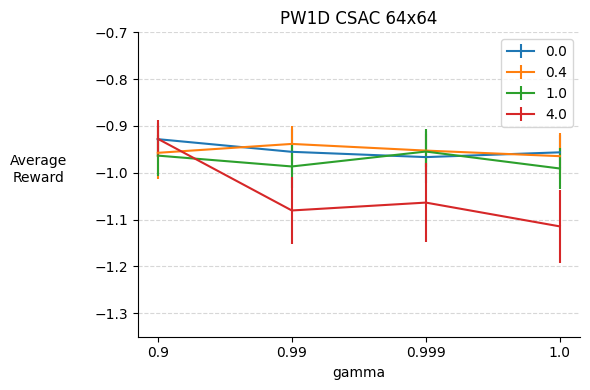

In [9]:
param_list = [('../results/centering_sweep/puckworld_1D/', 'puckworld1D_cont_CDiscSAC', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.7), #firstn=400, #logbase=10, 
                 title=r'PW1D CSAC 64x64', final=False)

### PPO

Filename	eta	gamma	Value

PPO_11.	4.0	0.999	-1.131	0.072
PPO_10.	1.0	0.999	-1.156	0.063
cPPO_1.	0.4	0.9	-1.000	0.062
cPPO_5.	0.4	0.99	-1.015	0.060
cPPO_7.	4.0	0.99	-1.007	0.064
cPPO_9.	0.4	0.999	-1.088	0.052
cPPO_2.	1.0	0.9	-0.980	0.054
PPO_13.	0.4	1.0	-1.079	0.057
cPPO_3.	4.0	0.9	-1.029	0.090
cPPO_4.	0.0	0.99	-1.136	0.063
PPO_14.	1.0	1.0	-1.139	0.066
PPO_12.	0.0	1.0	-1.597	0.095
cPPO_8.	0.0	0.999	-1.355	0.083
PPO_15.	4.0	1.0	-1.079	0.039
cPPO_0.	0.0	0.9	-1.053	0.090
cPPO_6.	1.0	0.99	-1.078	0.086
0 0.0
1 0.4
2 1.0
3 4.0


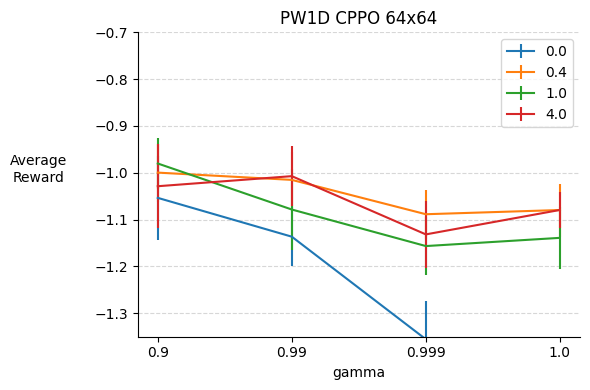

In [10]:
param_list = [('../results/centering_sweep/puckworld_1D/', 'puckworld1D_cont_CDiscPPO', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.7), #firstn=400, #logbase=10, 
                 title=r'PW1D CPPO 64x64', final=False)

/gpfs/work/naika/venvs/dev/lib64/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


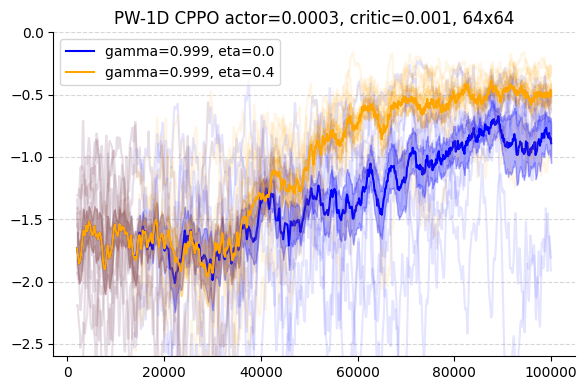

In [6]:
filenames = [('../results/centering_sweep/puckworld_1D/', 'puckworld1D_cont_CDiscPPO_8.npy'),
             ('../results/centering_sweep/puckworld_1D/', 'puckworld1D_cont_CDiscPPO_9.npy'),
            ]    

plot_learning_curve(filenames, item='reward', window=2000, ylims=(-2.6, 0),
                    title=r'PW-1D CPPO actor=0.0003, critic=0.001, 64x64', final=False, plot_all_runs=True, labels='gamma,eta')

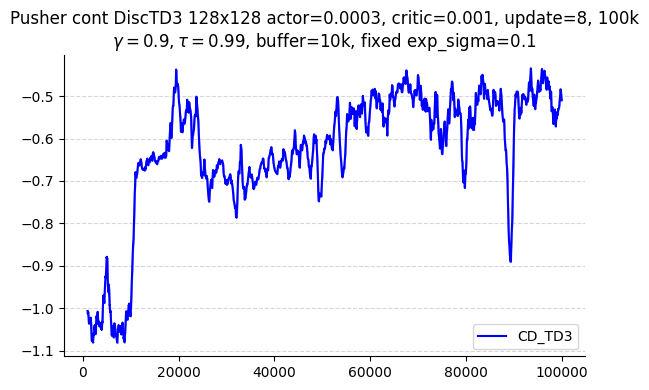

In [7]:
filenames = [('../results/test_exp/', 'pusher_cont_DiscTD3_gamma0.9_0.npy'),]
plot_learning_curve(filenames, item='reward', window=1000, final=False, plot_all_runs=True, #, ylims=(-10,0.5))
                    title='Pusher cont DiscTD3 128x128 actor=0.0003, critic=0.001, update=8, 100k\n' + r'$\gamma=0.9, \tau=0.99$, ' + 'buffer=10k, fixed exp_sigma=0.1')

## Sweep 2

Filename	eta	gamma	Value

DPG_14.	1.0	1	-1.192	0.082
DPG_15.	4.0	1	-1.221	0.072
DDPG_6.	1.0	0.99	-1.229	0.089
DPG_12.	0.0	1	-1.160	0.069
DPG_10.	1.0	0.999	-1.157	0.059
DDPG_4.	0.0	0.99	-1.211	0.086
DPG_11.	4.0	0.999	-1.221	0.075
DDPG_5.	0.4	0.99	-1.229	0.072
DPG_13.	0.4	1	-1.177	0.065
DDPG_9.	0.4	0.999	-1.251	0.074
DDPG_7.	4.0	0.99	-1.205	0.069
DDPG_8.	0.0	0.999	-1.237	0.087
DDPG_0.	0.0	0.9	-1.380	0.064
DDPG_3.	4.0	0.9	-1.410	0.068
DDPG_1.	0.4	0.9	-1.383	0.066
DDPG_2.	1.0	0.9	-1.413	0.070
0 0.0
1 0.4
2 1.0
3 4.0


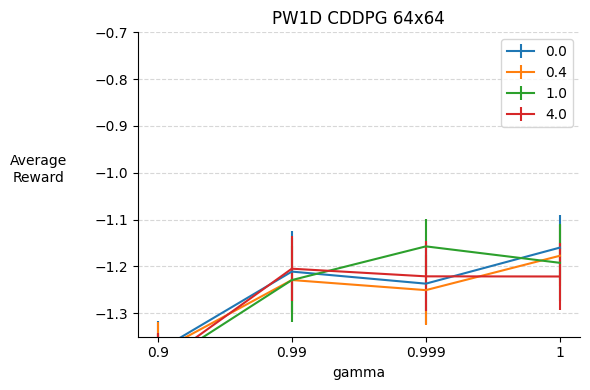

In [4]:
param_list = [('../results/centering_sweep_2/puckworld_1D/', 'puckworld1D_cont_CDiscDDPG', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.7), #firstn=400, #logbase=10, 
                 title=r'PW1D CDDPG 64x64', final=False)

Filename	eta	gamma	Value

TD3_14.	1.0	1.0	-1.296	0.058
cTD3_3.	4.0	0.9	-1.512	0.067
cTD3_2.	1.0	0.9	-1.502	0.067
cTD3_8.	0.0	0.999	-1.303	0.055
cTD3_5.	0.4	0.99	-1.358	0.068
cTD3_0.	0.0	0.9	-1.402	0.057
cTD3_7.	4.0	0.99	-1.363	0.055
TD3_13.	0.4	1.0	-1.291	0.051
cTD3_4.	0.0	0.99	-1.292	0.040
TD3_11.	4.0	0.999	-1.319	0.065
TD3_15.	4.0	1.0	-1.293	0.041
cTD3_9.	0.4	0.999	-1.263	0.047
cTD3_6.	1.0	0.99	-1.344	0.061
TD3_12.	0.0	1.0	-1.297	0.062
TD3_10.	1.0	0.999	-1.293	0.053
cTD3_1.	0.4	0.9	-1.496	0.039
0 0.0
1 0.4
2 1.0
3 4.0


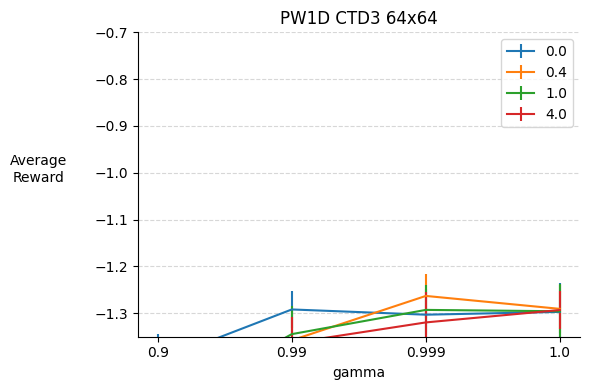

In [6]:
param_list = [('../results/centering_sweep_2/puckworld_1D/', 'puckworld1D_cont_CDiscTD3', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.7), #firstn=400, #logbase=10, 
                 title=r'PW1D CTD3 64x64', final=False)

Filename	eta	gamma	Value

SAC_15.	4.0	1.0	-1.198	0.048
cSAC_0.	0.0	0.9	-1.416	0.044
cSAC_1.	0.4	0.9	-1.379	0.050
SAC_12.	0.0	1.0	-1.172	0.043
SAC_11.	4.0	0.999	-1.207	0.050
cSAC_6.	1.0	0.99	-1.175	0.044
SAC_14.	1.0	1.0	-1.177	0.043
cSAC_4.	0.0	0.99	-1.167	0.048
cSAC_8.	0.0	0.999	-1.153	0.049
cSAC_9.	0.4	0.999	-1.147	0.040
SAC_13.	0.4	1.0	-1.175	0.040
cSAC_7.	4.0	0.99	-1.226	0.046
cSAC_2.	1.0	0.9	-1.381	0.055
cSAC_5.	0.4	0.99	-1.208	0.053
SAC_10.	1.0	0.999	-1.157	0.032
cSAC_3.	4.0	0.9	-1.426	0.053
0 0.0
1 0.4
2 1.0
3 4.0


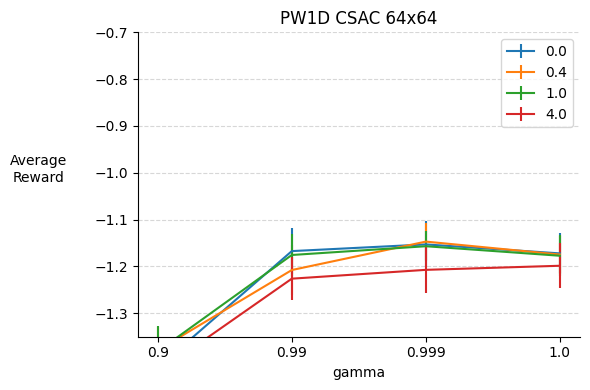

In [7]:
param_list = [('../results/centering_sweep_2/puckworld_1D/', 'puckworld1D_cont_CDiscSAC', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.7), #firstn=400, #logbase=10, 
                 title=r'PW1D CSAC 64x64', final=False)

Filename	eta	gamma	Value

PPO_11.	4.0	0.999	-1.189	0.123
PPO_10.	1.0	0.999	-1.250	0.114
cPPO_1.	0.4	0.9	-0.980	0.072
cPPO_5.	0.4	0.99	-0.976	0.081
cPPO_7.	4.0	0.99	-1.083	0.124
cPPO_9.	0.4	0.999	-1.243	0.116
cPPO_2.	1.0	0.9	-0.949	0.063
PPO_13.	0.4	1.0	-1.194	0.107
cPPO_3.	4.0	0.9	-0.999	0.088
cPPO_4.	0.0	0.99	-1.392	0.131
PPO_14.	1.0	1.0	-1.241	0.128
PPO_12.	0.0	1.0	-1.713	0.073
cPPO_8.	0.0	0.999	-1.693	0.091
PPO_15.	4.0	1.0	-1.204	0.118
cPPO_0.	0.0	0.9	-1.155	0.127
cPPO_6.	1.0	0.99	-1.061	0.117
0 0.0
1 0.4
2 1.0
3 4.0


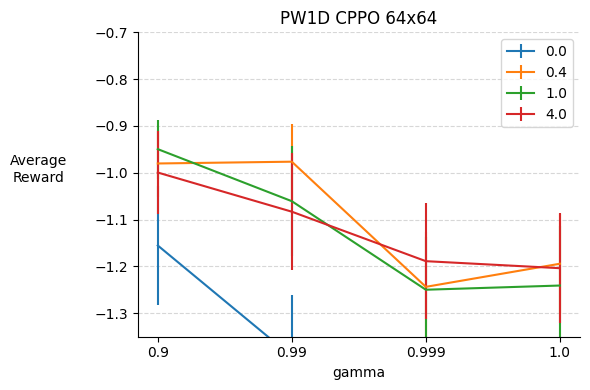

In [8]:
param_list = [('../results/centering_sweep_2/puckworld_1D/', 'puckworld1D_cont_CDiscPPO', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.7), #firstn=400, #logbase=10, 
                 title=r'PW1D CPPO 64x64', final=False)

/tmp/ipykernel_467929/3739522611.py:167: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/gpfs/work/naika/venvs/dev/lib64/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


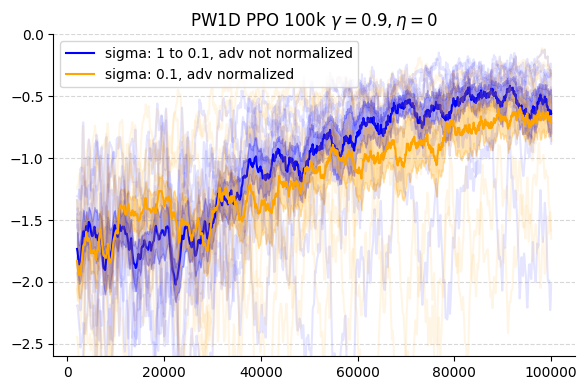

In [16]:
filenames = [('../results/centering_sweep/puckworld_1D/', 'puckworld1D_cont_CDiscPPO_0.npy', 'sigma: 1 to 0.1, adv not normalized'),
             ('../results/centering_sweep_2/puckworld_1D/', 'puckworld1D_cont_CDiscPPO_0.npy', 'sigma: 0.1, adv normalized'),]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-2.6,0.0),
                    title=r'PW1D PPO 100k $\gamma=0.9, \eta=0$', labels='')

## Sweep 3

Filename	eta	gamma	Value

DPG_14.	1.0	1	-1.051	0.112
DPG_15.	4.0	1	-0.943	0.089
DDPG_6.	1.0	0.99	-0.913	0.093
DPG_12.	0.0	1	-1.108	0.145
DPG_10.	1.0	0.999	-1.002	0.112
DDPG_4.	0.0	0.99	-0.962	0.092
DPG_11.	4.0	0.999	-1.033	0.124
DDPG_5.	0.4	0.99	-1.036	0.122
DPG_13.	0.4	1	-0.920	0.091
DDPG_9.	0.4	0.999	-1.031	0.118
DDPG_7.	4.0	0.99	-1.090	0.122
DDPG_8.	0.0	0.999	-0.984	0.108
DDPG_0.	0.0	0.9	-1.209	0.080
DDPG_3.	4.0	0.9	-1.266	0.045
DDPG_1.	0.4	0.9	-1.320	0.065
DDPG_2.	1.0	0.9	-1.158	0.075
0 0.0
1 0.4
2 1.0
3 4.0


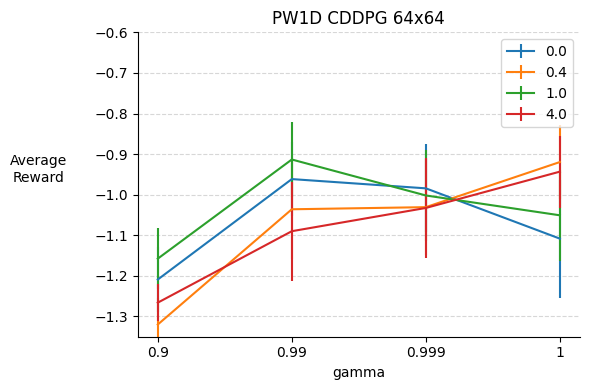

In [10]:
param_list = [('../results/centering_sweep_3/puckworld_1D/', 'puckworld1D_cont_CDiscDDPG', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.6), #firstn=400, #logbase=10, 
                 title=r'PW1D CDDPG 64x64', final=False)

Filename	eta	gamma	Value

TD3_14.	1.0	1.0	-1.148	0.090
cTD3_3.	4.0	0.9	-1.421	0.076
cTD3_2.	1.0	0.9	-1.358	0.071
cTD3_8.	0.0	0.999	-1.050	0.104
cTD3_5.	0.4	0.99	-1.011	0.108
cTD3_0.	0.0	0.9	-1.344	0.078
cTD3_7.	4.0	0.99	-1.240	0.074
TD3_13.	0.4	1.0	-1.079	0.092
cTD3_4.	0.0	0.99	-0.998	0.071
TD3_11.	4.0	0.999	-1.273	0.080
TD3_15.	4.0	1.0	-1.202	0.059
cTD3_9.	0.4	0.999	-1.026	0.095
cTD3_6.	1.0	0.99	-1.127	0.089
TD3_12.	0.0	1.0	-0.990	0.086
TD3_10.	1.0	0.999	-1.101	0.097
cTD3_1.	0.4	0.9	-1.343	0.089
0 0.0
1 0.4
2 1.0
3 4.0


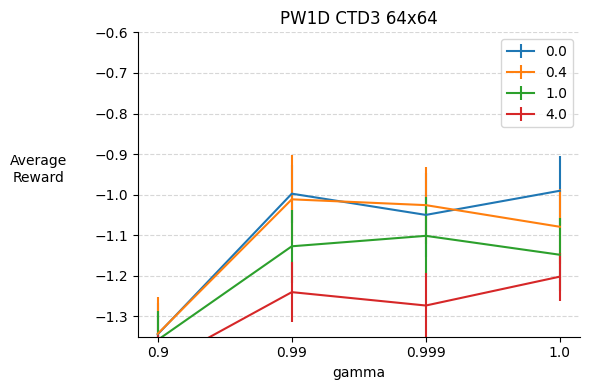

In [11]:
param_list = [('../results/centering_sweep_3/puckworld_1D/', 'puckworld1D_cont_CDiscTD3', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.6), #firstn=400, #logbase=10, 
                 title=r'PW1D CTD3 64x64', final=False)

Filename	eta	gamma	Value

SAC_15.	4.0	1.0	-1.273	0.073
cSAC_0.	0.0	0.9	-1.381	0.056
cSAC_1.	0.4	0.9	-1.334	0.068
SAC_12.	0.0	1.0	-1.049	0.096
SAC_11.	4.0	0.999	-1.230	0.053
cSAC_6.	1.0	0.99	-1.157	0.061
SAC_14.	1.0	1.0	-1.096	0.070
cSAC_4.	0.0	0.99	-0.998	0.071
cSAC_8.	0.0	0.999	-1.041	0.074
cSAC_9.	0.4	0.999	-1.055	0.072
SAC_13.	0.4	1.0	-1.067	0.066
cSAC_7.	4.0	0.99	-1.208	0.079
cSAC_2.	1.0	0.9	-1.332	0.064
cSAC_5.	0.4	0.99	-1.073	0.049
SAC_10.	1.0	0.999	-1.138	0.075
cSAC_3.	4.0	0.9	-1.352	0.046
0 0.0
1 0.4
2 1.0
3 4.0


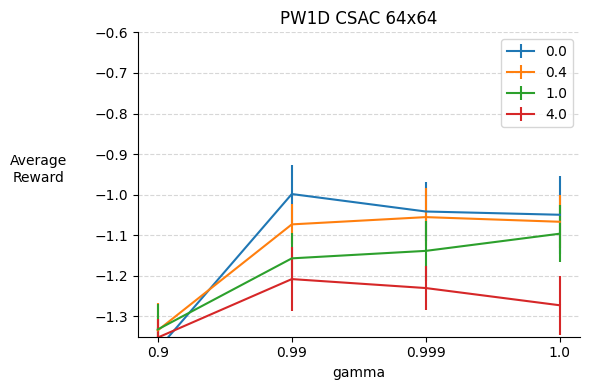

In [12]:
param_list = [('../results/centering_sweep_3/puckworld_1D/', 'puckworld1D_cont_CDiscSAC', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.6), #firstn=400, #logbase=10, 
                 title=r'PW1D CSAC 64x64', final=False)

Filename	eta	gamma	Value

PPO_11.	4.0	0.999	-0.834	0.108
PPO_10.	1.0	0.999	-0.795	0.053
cPPO_1.	0.4	0.9	-0.680	0.033
cPPO_5.	0.4	0.99	-0.712	0.036
cPPO_7.	4.0	0.99	-0.728	0.039
cPPO_9.	0.4	0.999	-0.762	0.050
cPPO_2.	1.0	0.9	-0.679	0.031
PPO_13.	0.4	1.0	-0.895	0.115
cPPO_3.	4.0	0.9	-0.686	0.034
cPPO_4.	0.0	0.99	-1.002	0.125
PPO_14.	1.0	1.0	-0.868	0.130
PPO_12.	0.0	1.0	-1.202	0.103
cPPO_8.	0.0	0.999	-1.279	0.144
PPO_15.	4.0	1.0	-0.982	0.152
cPPO_0.	0.0	0.9	-0.693	0.040
cPPO_6.	1.0	0.99	-0.691	0.026
0 0.0
1 0.4
2 1.0
3 4.0


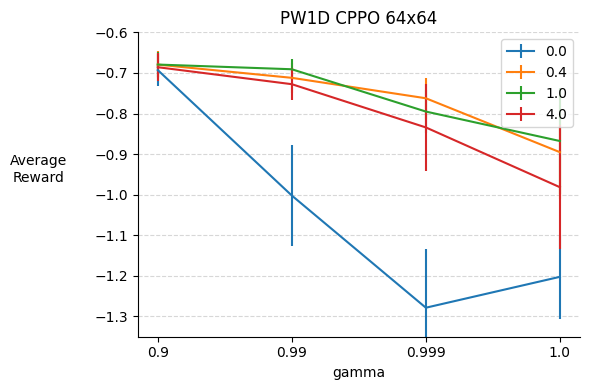

In [5]:
param_list = [('../results/centering_sweep_3/puckworld_1D/', 'puckworld1D_cont_CDiscPPO', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.6), #firstn=400, #logbase=10, 
                 title=r'PW1D CPPO 64x64', final=False)

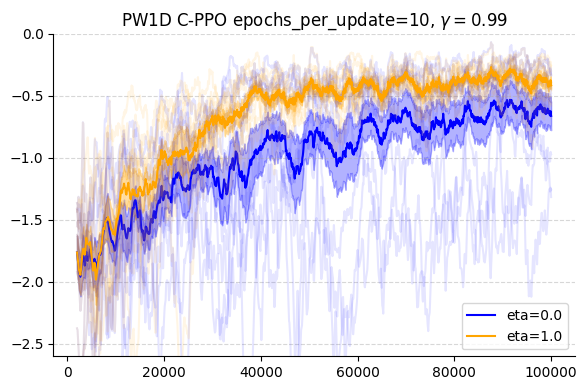

In [7]:
filenames = [('../results/centering_sweep_3/puckworld_1D/', 'puckworld1D_cont_CDiscPPO_4.npy', ''),
             ('../results/centering_sweep_3/puckworld_1D/', 'puckworld1D_cont_CDiscPPO_6.npy', ''),]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-2.6,0.0),
                    title=r'PW1D C-PPO epochs_per_update=10, $\gamma=0.99$', labels='eta')

/tmp/ipykernel_2398661/3739522611.py:167: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


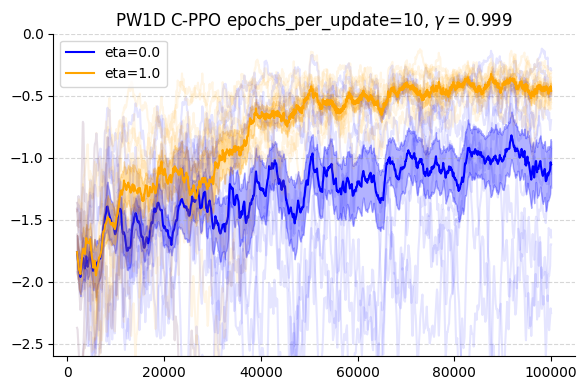

In [9]:
filenames = [('../results/centering_sweep_3/puckworld_1D/', 'puckworld1D_cont_CDiscPPO_8.npy', ''),
             ('../results/centering_sweep_3/puckworld_1D/', 'puckworld1D_cont_CDiscPPO_10.npy', ''),]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-2.6,0.0),
                    title=r'PW1D C-PPO epochs_per_update=10, $\gamma=0.999$', labels='eta')

## Sweep 4

Filename	eta	gamma	Value

DPG_14.	1.0	1	-0.759	0.040
DPG_15.	4.0	1	-0.780	0.049
DDPG_6.	1.0	0.99	-0.736	0.041
DPG_12.	0.0	1	-0.758	0.027
DPG_10.	1.0	0.999	-0.774	0.032
DDPG_4.	0.0	0.99	-0.718	0.026
DPG_11.	4.0	0.999	-0.819	0.073
DDPG_5.	0.4	0.99	-0.736	0.032
DPG_13.	0.4	1	-0.757	0.032
DDPG_9.	0.4	0.999	-0.753	0.032
DDPG_7.	4.0	0.99	-0.768	0.048
DDPG_8.	0.0	0.999	-0.760	0.030
DDPG_0.	0.0	0.9	-0.740	0.048
DDPG_3.	4.0	0.9	-0.800	0.068
DDPG_1.	0.4	0.9	-0.739	0.043
DDPG_2.	1.0	0.9	-0.762	0.052
0 0.0
1 0.4
2 1.0
3 4.0


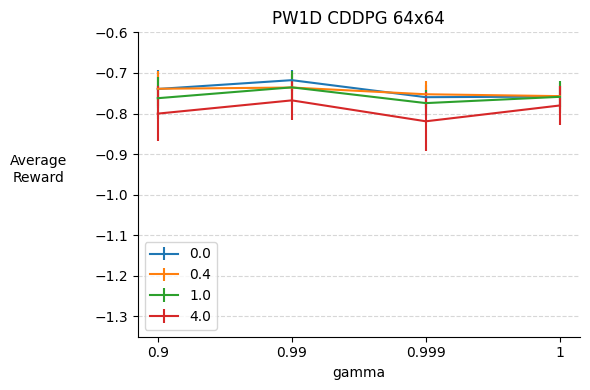

In [3]:
param_list = [('../results/centering_sweep_4/puckworld_1D/', 'puckworld1D_cont_CDiscDDPG', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.6), #firstn=400, #logbase=10, 
                 title=r'PW1D CDDPG 64x64', final=False)

Filename	eta	gamma	Value

TD3_14.	1.0	1.0	-0.801	0.035
cTD3_3.	4.0	0.9	-1.295	0.102
cTD3_2.	1.0	0.9	-0.915	0.073
cTD3_8.	0.0	0.999	-0.755	0.021
cTD3_5.	0.4	0.99	-0.728	0.025
cTD3_0.	0.0	0.9	-0.865	0.060
cTD3_7.	4.0	0.99	-1.048	0.095
TD3_13.	0.4	1.0	-0.769	0.032
cTD3_4.	0.0	0.99	-0.814	0.045
TD3_11.	4.0	0.999	-1.107	0.086
TD3_15.	4.0	1.0	-1.142	0.093
cTD3_9.	0.4	0.999	-0.748	0.027
cTD3_6.	1.0	0.99	-0.825	0.036
TD3_12.	0.0	1.0	-0.776	0.033
TD3_10.	1.0	0.999	-0.804	0.037
cTD3_1.	0.4	0.9	-0.955	0.048
0 0.0
1 0.4
2 1.0
3 4.0


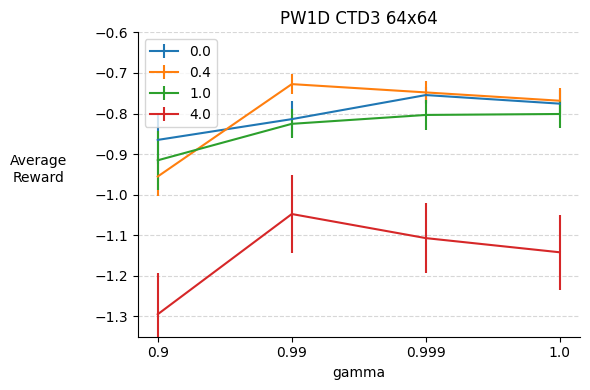

In [6]:
param_list = [('../results/centering_sweep_4/puckworld_1D/', 'puckworld1D_cont_CDiscTD3', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.6), #firstn=400, #logbase=10, 
                 title=r'PW1D CTD3 64x64', final=False)

Filename	eta	gamma	Value

SAC_15.	4.0	1.0	-1.009	0.056
cSAC_0.	0.0	0.9	-0.773	0.031
cSAC_1.	0.4	0.9	-0.822	0.036
SAC_12.	0.0	1.0	-0.748	0.030
SAC_11.	4.0	0.999	-1.042	0.058
cSAC_6.	1.0	0.99	-0.779	0.025
SAC_14.	1.0	1.0	-0.808	0.025
cSAC_4.	0.0	0.99	-0.710	0.025
cSAC_8.	0.0	0.999	-0.721	0.030
cSAC_9.	0.4	0.999	-0.740	0.021
SAC_13.	0.4	1.0	-0.759	0.018
cSAC_7.	4.0	0.99	-0.899	0.047
cSAC_2.	1.0	0.9	-0.848	0.041
cSAC_5.	0.4	0.99	-0.732	0.028
SAC_10.	1.0	0.999	-0.799	0.031
cSAC_3.	4.0	0.9	-0.983	0.075
0 0.0
1 0.4
2 1.0
3 4.0


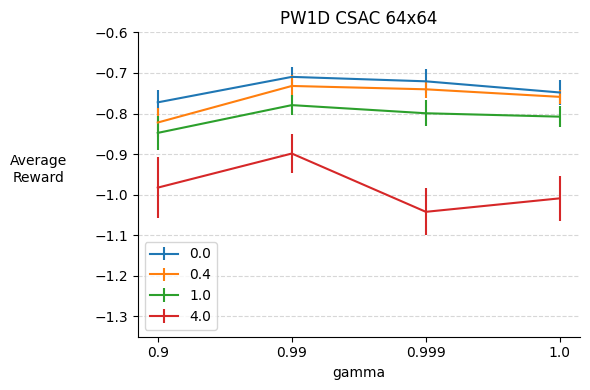

In [7]:
param_list = [('../results/centering_sweep_4/puckworld_1D/', 'puckworld1D_cont_CDiscSAC', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.6), #firstn=400, #logbase=10, 
                 title=r'PW1D CSAC 64x64', final=False)

Filename	eta	gamma	Value

PPO_11.	4.0	0.999	-0.844	0.113
PPO_10.	1.0	0.999	-0.839	0.093
cPPO_1.	0.4	0.9	-0.721	0.058
cPPO_5.	0.4	0.99	-0.725	0.053
cPPO_7.	4.0	0.99	-0.700	0.043
cPPO_9.	0.4	0.999	-0.788	0.058
cPPO_2.	1.0	0.9	-0.715	0.041
PPO_13.	0.4	1.0	-0.819	0.063
cPPO_3.	4.0	0.9	-0.730	0.059
cPPO_4.	0.0	0.99	-0.799	0.072
PPO_14.	1.0	1.0	-0.795	0.047
PPO_12.	0.0	1.0	-0.898	0.056
cPPO_8.	0.0	0.999	-0.900	0.077
PPO_15.	4.0	1.0	-0.810	0.063
cPPO_0.	0.0	0.9	-0.724	0.036
cPPO_6.	1.0	0.99	-0.702	0.037
0 0.0
1 0.4
2 1.0
3 4.0


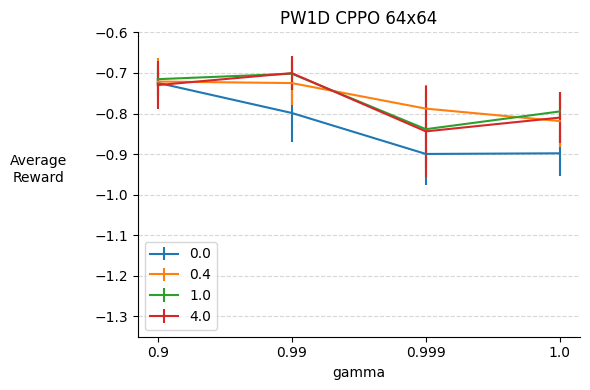

In [13]:
param_list = [('../results/centering_sweep_4/puckworld_1D/', 'puckworld1D_cont_CDiscPPO', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-1.35, -0.6), #firstn=400, #logbase=10, 
                 title=r'PW1D CPPO 64x64', final=False)

## Pendulum

### Sweep 4 (continuation of PW1D)

Filename	eta	gamma	Value

DPG_10.	1.0	0.999	-4.772	0.642
DDPG_7.	4.0	0.99	-5.456	0.826
DDPG_0.	0.0	0.9	-3.668	0.189
DDPG_1.	0.4	0.9	-3.963	0.521
DDPG_5.	0.4	0.99	-4.074	0.379
DPG_15.	4.0	1	-5.486	0.843
DDPG_6.	1.0	0.99	-3.799	0.278
DPG_14.	1.0	1	-4.969	0.654
DDPG_4.	0.0	0.99	-4.246	0.570
DDPG_8.	0.0	0.999	-4.310	0.481
DDPG_9.	0.4	0.999	-5.664	0.655
DPG_11.	4.0	0.999	-6.505	0.820
DDPG_2.	1.0	0.9	-5.715	0.876
DPG_12.	0.0	1	-4.762	0.634
DPG_13.	0.4	1	-4.407	0.448
DDPG_3.	4.0	0.9	-6.067	0.824
0 0.0
1 0.4
2 1.0
3 4.0


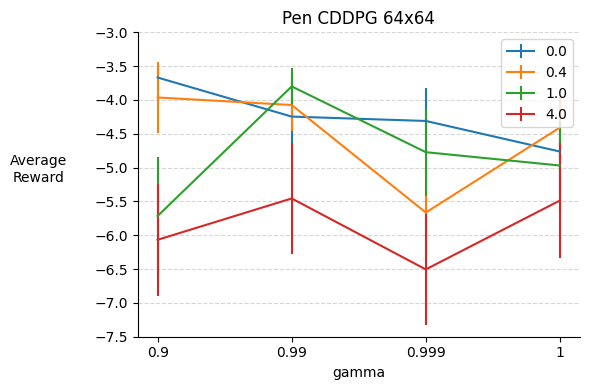

In [9]:
param_list = [('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscDDPG', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-7.5, -3), #firstn=400, #logbase=10, 
                 title=r'Pen CDDPG 64x64', final=False)

Filename	eta	gamma	Value

cTD3_1.	0.4	0.9	-5.188	0.825
cTD3_4.	0.0	0.99	-5.652	0.697
cTD3_7.	4.0	0.99	-5.132	0.688
cTD3_9.	0.4	0.999	-5.509	0.666
TD3_12.	0.0	1.0	-6.151	0.768
TD3_15.	4.0	1.0	-7.397	0.479
TD3_14.	1.0	1.0	-5.960	0.687
cTD3_2.	1.0	0.9	-5.213	0.836
cTD3_8.	0.0	0.999	-6.496	0.831
TD3_10.	1.0	0.999	-5.819	0.699
TD3_11.	4.0	0.999	-6.121	0.414
cTD3_6.	1.0	0.99	-6.291	0.755
TD3_13.	0.4	1.0	-4.994	0.664
cTD3_0.	0.0	0.9	-5.332	0.843
cTD3_3.	4.0	0.9	-6.239	0.901
cTD3_5.	0.4	0.99	-6.292	0.777
0 0.0
1 0.4
2 1.0
3 4.0


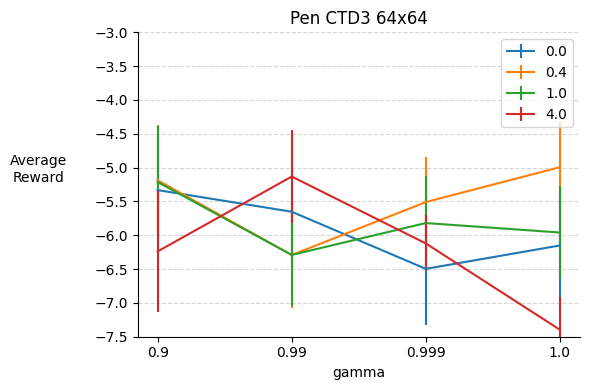

In [11]:
param_list = [('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscTD3', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                y_lims=(-7.5, -3), #firstn=400, #logbase=10, 
                 title=r'Pen CTD3 64x64', final=False)

Filename	eta	gamma	Value

SAC_10.	1.0	0.999	-5.539	0.198
cSAC_0.	0.0	0.9	-4.475	0.193
SAC_14.	1.0	1.0	-5.642	0.209
SAC_15.	4.0	1.0	-6.125	0.119
cSAC_7.	4.0	0.99	-5.450	0.243
cSAC_3.	4.0	0.9	-4.878	0.272
cSAC_5.	0.4	0.99	-5.340	0.187
SAC_12.	0.0	1.0	-5.507	0.351
cSAC_2.	1.0	0.9	-4.598	0.273
cSAC_9.	0.4	0.999	-5.000	0.259
SAC_11.	4.0	0.999	-5.901	0.152
cSAC_6.	1.0	0.99	-5.328	0.132
cSAC_8.	0.0	0.999	-5.919	0.330
cSAC_1.	0.4	0.9	-4.513	0.306
SAC_13.	0.4	1.0	-5.519	0.128
cSAC_4.	0.0	0.99	-5.129	0.239
0 0.0
1 0.4
2 1.0
3 4.0


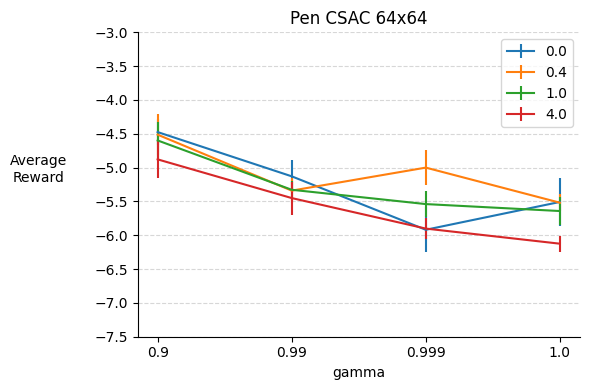

In [12]:
param_list = [('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscSAC', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                y_lims=(-7.5, -3), #firstn=400, #logbase=10, 
                 title=r'Pen CSAC 64x64', final=False)

Filename	eta	gamma	Value

PPO_13.	0.4	1.0	-3.738	0.042
cPPO_5.	0.4	0.99	-3.537	0.058
cPPO_2.	1.0	0.9	-3.401	0.022
PPO_14.	1.0	1.0	-3.740	0.052
PPO_10.	1.0	0.999	-3.711	0.033
PPO_15.	4.0	1.0	-3.789	0.039
PPO_11.	4.0	0.999	-3.707	0.046
cPPO_9.	0.4	0.999	-3.645	0.037
cPPO_3.	4.0	0.9	-3.355	0.024
cPPO_7.	4.0	0.99	-3.624	0.031
cPPO_8.	0.0	0.999	-5.192	0.438
cPPO_6.	1.0	0.99	-3.597	0.036
cPPO_4.	0.0	0.99	-3.894	0.060
PPO_12.	0.0	1.0	-5.848	0.532
cPPO_1.	0.4	0.9	-3.352	0.031
cPPO_0.	0.0	0.9	-3.430	0.034
0 0.0
1 0.4
2 1.0
3 4.0


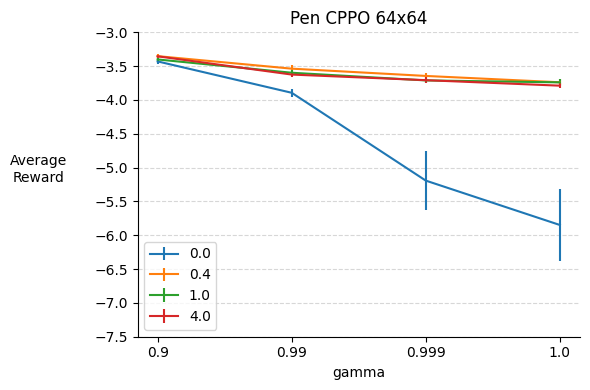

In [ ]:
param_list = [('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscPPO', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-7.5, -3), #firstn=400, #logbase=10, 
                 title=r'Pen CPPO 64x64', final=False)

/tmp/ipykernel_308552/497675650.py:167: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


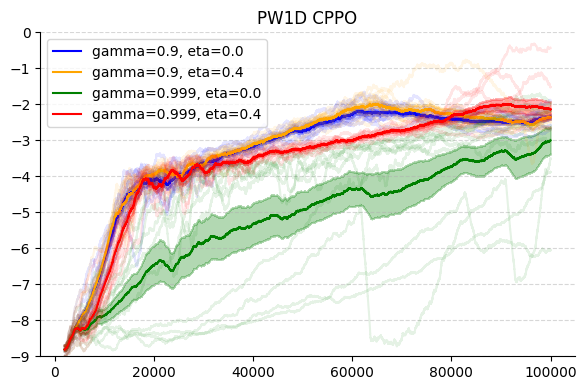

In [22]:
filenames = [('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscPPO_0.npy', ''),
             ('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscPPO_1.npy', ''),
             ('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscPPO_8.npy', ''),
             ('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscPPO_9.npy', ''),]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-9,0.0),
                    title=r'PW1D CPPO', labels='gamma,eta')

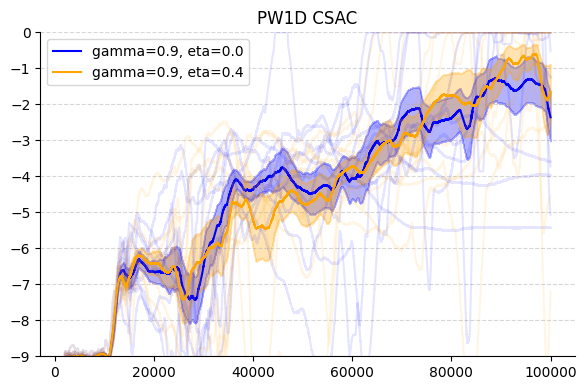

In [23]:
filenames = [('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscSAC_0.npy', ''),
             ('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscSAC_1.npy', ''),
            #  ('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscSAC_8.npy', ''),
            #  ('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscSAC_9.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-9,0.0),
                    title=r'PW1D CSAC', labels='gamma,eta')

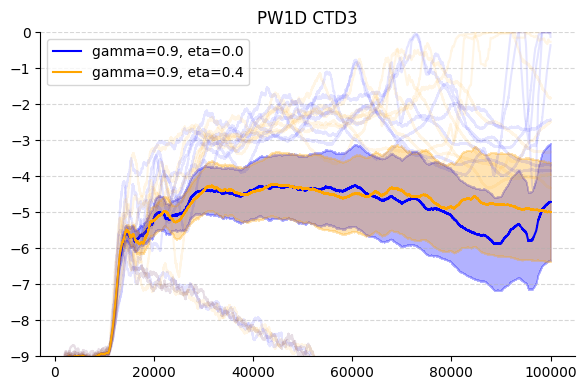

In [4]:
filenames = [('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscTD3_0.npy', ''),
             ('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscTD3_1.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-9,0.0),
                    title=r'PW1D CTD3', labels='gamma,eta')

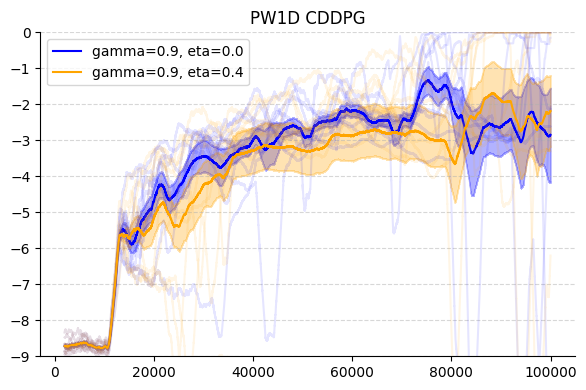

In [5]:
filenames = [('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscDDPG_0.npy', ''),
             ('../results/centering_sweep_4/pendulum/', 'pendulum_cont_CDiscDDPG_1.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-9,0.0),
                    title=r'PW1D CDDPG', labels='gamma,eta')

#### Sweep 4 (with fixed exploration sigma for DDPG and TD3)

Filename	eta	gamma	Value

DPG_10.	1.0	0.999	-4.905	0.280
DDPG_7.	4.0	0.99	-5.360	0.611
DDPG_0.	0.0	0.9	-4.508	0.365
DDPG_1.	0.4	0.9	-5.070	0.685
DDPG_5.	0.4	0.99	-5.033	0.434
DPG_15.	4.0	1	-5.237	0.482
DDPG_6.	1.0	0.99	-5.012	0.461
DPG_14.	1.0	1	-5.782	0.568
DDPG_4.	0.0	0.99	-4.846	0.266
DDPG_8.	0.0	0.999	-5.509	0.474
DDPG_9.	0.4	0.999	-5.866	0.681
DPG_11.	4.0	0.999	-6.013	0.752
DDPG_2.	1.0	0.9	-5.593	0.989
DPG_12.	0.0	1	-5.185	0.483
DPG_13.	0.4	1	-4.804	0.170
DDPG_3.	4.0	0.9	-4.793	0.880
0 0.0
1 0.4
2 1.0
3 4.0


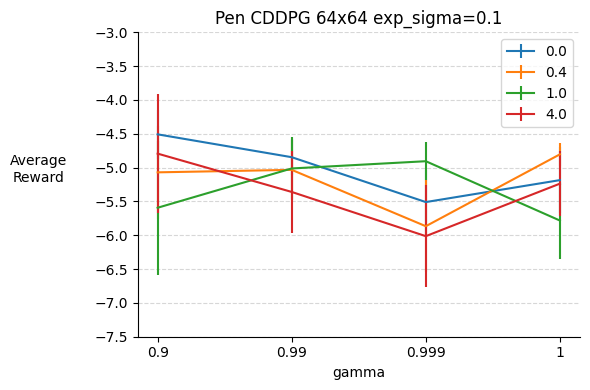

In [4]:
param_list = [('../results/centering_sweep_4/pendulum/fixed_exp_sigma/', 'pendulum_cont_CDiscDDPG', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-7.5, -3), #firstn=400, #logbase=10, 
                 title=r'Pen CDDPG 64x64 exp_sigma=0.1', final=False)

Filename	eta	gamma	Value

cTD3_1.	0.4	0.9	-4.969	0.551
cTD3_4.	0.0	0.99	-5.813	0.593
cTD3_7.	4.0	0.99	-6.211	0.444
cTD3_9.	0.4	0.999	-6.250	0.480
TD3_12.	0.0	1.0	-5.938	0.443
TD3_15.	4.0	1.0	-7.120	0.435
TD3_14.	1.0	1.0	-5.761	0.368
cTD3_2.	1.0	0.9	-6.027	0.772
cTD3_8.	0.0	0.999	-6.178	0.712
TD3_10.	1.0	0.999	-5.401	0.294
TD3_11.	4.0	0.999	-6.980	0.435
cTD3_6.	1.0	0.99	-6.071	0.539
TD3_13.	0.4	1.0	-5.142	0.215
cTD3_0.	0.0	0.9	-5.712	0.694
cTD3_3.	4.0	0.9	-6.509	0.745
cTD3_5.	0.4	0.99	-5.360	0.548
0 0.0
1 0.4
2 1.0
3 4.0


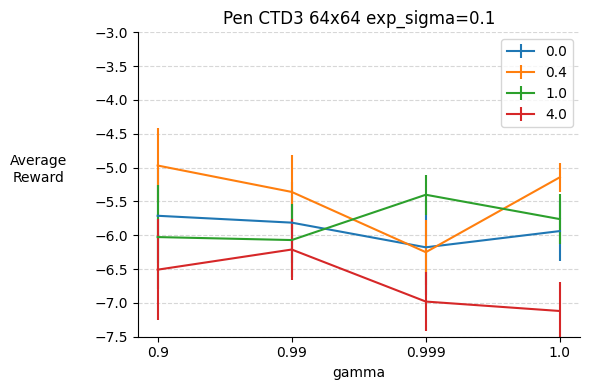

In [5]:
param_list = [('../results/centering_sweep_4/pendulum/fixed_exp_sigma/', 'pendulum_cont_CDiscTD3', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-7.5, -3), #firstn=400, #logbase=10, 
                 title=r'Pen CTD3 64x64 exp_sigma=0.1', final=False)

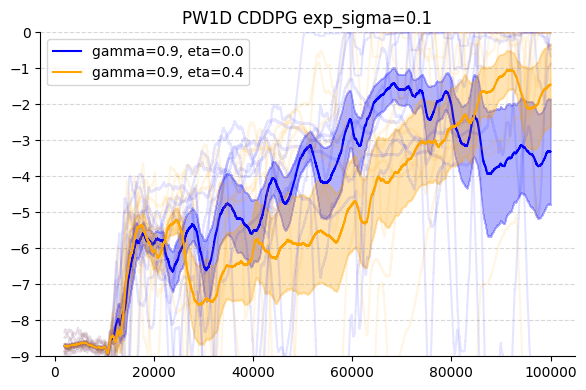

In [7]:
filenames = [('../results/centering_sweep_4/pendulum/fixed_exp_sigma/', 'pendulum_cont_CDiscDDPG_0.npy', ''),
             ('../results/centering_sweep_4/pendulum/fixed_exp_sigma/', 'pendulum_cont_CDiscDDPG_1.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-9,0.0),
                    title=r'PW1D CDDPG exp_sigma=0.1', labels='gamma,eta')

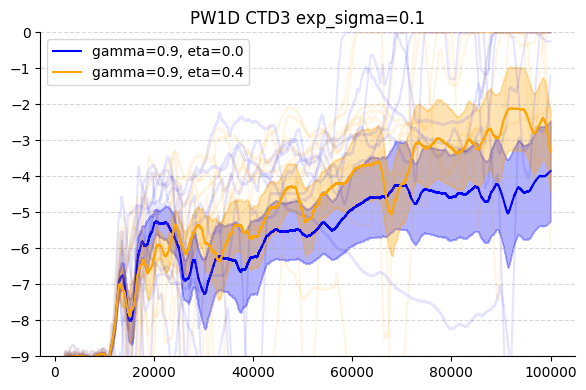

In [6]:
filenames = [('../results/centering_sweep_4/pendulum/fixed_exp_sigma/', 'pendulum_cont_CDiscTD3_0.npy', ''),
             ('../results/centering_sweep_4/pendulum/fixed_exp_sigma/', 'pendulum_cont_CDiscTD3_1.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-9,0.0),
                    title=r'PW1D CTD3 exp_sigma=0.1', labels='gamma,eta')

## Reacher

Filename	eta	gamma	Value

DDPG_4.	0.0	0.99	-0.362	0.008
DDPG_8.	0.0	0.999	-0.450	0.036
DPG_14.	1.0	1	-0.534	0.070
DPG_10.	1.0	0.999	-0.461	0.023
DDPG_1.	0.4	0.9	-0.288	0.001
DDPG_2.	1.0	0.9	-0.289	0.001
DPG_13.	0.4	1	-0.449	0.019
DDPG_7.	4.0	0.99	-0.373	0.007
DPG_12.	0.0	1	-0.545	0.028
DDPG_3.	4.0	0.9	-0.288	0.001
DPG_11.	4.0	0.999	-0.448	0.020
DDPG_5.	0.4	0.99	-0.363	0.008
DDPG_6.	1.0	0.99	-0.372	0.009
DDPG_0.	0.0	0.9	-0.290	0.001
DDPG_9.	0.4	0.999	-0.449	0.021
DPG_15.	4.0	1	-0.497	0.053
0 0.0
1 0.4
2 1.0
3 4.0


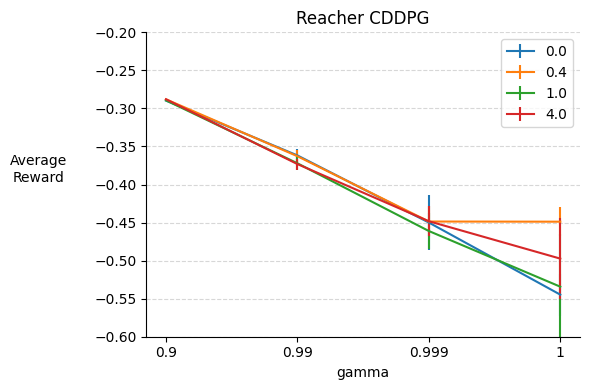

In [16]:
param_list = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-0.6, -0.2), #firstn=400, #logbase=10, 
                 title=r'Reacher CDDPG', final=False)

/tmp/ipykernel_3819432/497675650.py:167: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/gpfs/work/naika/venvs/dev/lib64/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


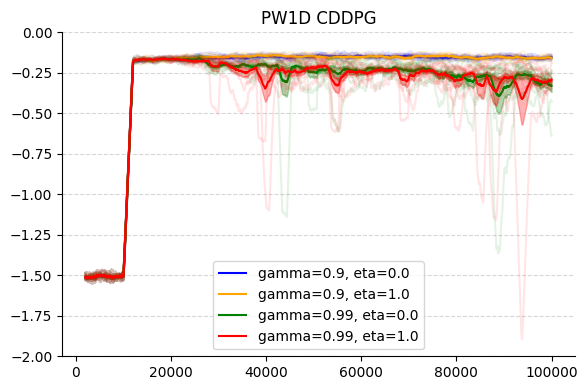

In [28]:
filenames = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG_0.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG_2.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG_4.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG_6.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-2,0.0),
                    title=r'PW1D CDDPG', labels='gamma,eta')

Filename	eta	gamma	Value

DDPG_4.	0.0	0.99	-0.288	0.006
DDPG_8.	0.0	0.999	-0.372	0.025
DPG_14.	1.0	1	-0.388	0.032
DPG_10.	1.0	0.999	-0.357	0.019
DDPG_1.	0.4	0.9	-0.221	0.001
DDPG_2.	1.0	0.9	-0.220	0.001
DPG_13.	0.4	1	-0.412	0.031
DDPG_7.	4.0	0.99	-0.294	0.006
DPG_12.	0.0	1	-0.377	0.028
DDPG_3.	4.0	0.9	-0.220	0.001
DPG_11.	4.0	0.999	-0.376	0.022
DDPG_5.	0.4	0.99	-0.283	0.005
DDPG_6.	1.0	0.99	-0.279	0.005
DDPG_0.	0.0	0.9	-0.220	0.001
DDPG_9.	0.4	0.999	-0.367	0.023
DPG_15.	4.0	1	-0.360	0.006
0 0.0
1 0.4
2 1.0
3 4.0


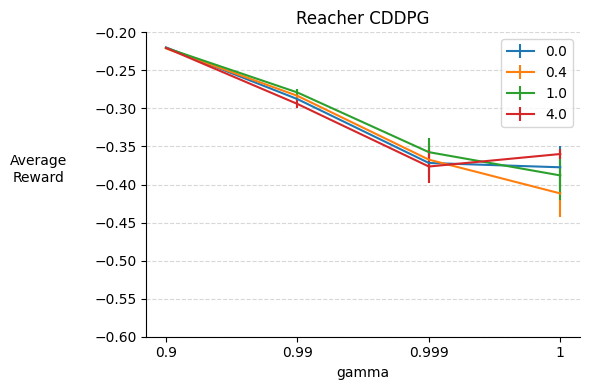

In [30]:
param_list = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-0.6, -0.2), #firstn=400, #logbase=10, 
                 title=r'Reacher CDDPG', final=False)

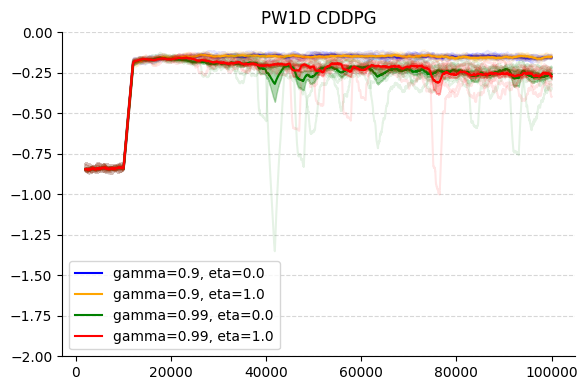

In [31]:
filenames = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG_0.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG_2.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG_4.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscDDPG_6.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-2,0.0),
                    title=r'PW1D CDDPG', labels='gamma,eta')

Filename	eta	gamma	Value

cTD3_6.	1.0	0.99	-0.274	0.005
TD3_14.	1.0	1.0	-0.358	0.008
TD3_11.	4.0	0.999	-0.560	0.018
cTD3_0.	0.0	0.9	-0.215	0.001
TD3_15.	4.0	1.0	-0.532	0.016
cTD3_3.	4.0	0.9	-0.217	0.001
cTD3_8.	0.0	0.999	-0.230	0.003
TD3_10.	1.0	0.999	-0.382	0.016
TD3_12.	0.0	1.0	-0.236	0.004
cTD3_7.	4.0	0.99	-0.433	0.013
cTD3_4.	0.0	0.99	-0.220	0.002
cTD3_2.	1.0	0.9	-0.215	0.001
TD3_13.	0.4	1.0	-0.299	0.007
cTD3_9.	0.4	0.999	-0.284	0.005
cTD3_1.	0.4	0.9	-0.212	0.001
cTD3_5.	0.4	0.99	-0.237	0.004
0 0.0
1 0.4
2 1.0
3 4.0


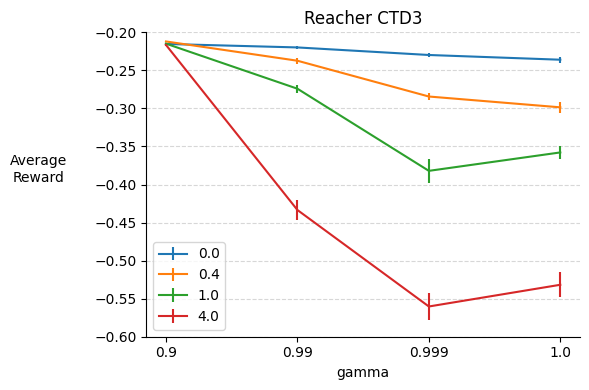

In [17]:
param_list = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscTD3', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-0.6, -0.2), #firstn=400, #logbase=10, 
                 title=r'Reacher CTD3', final=False)

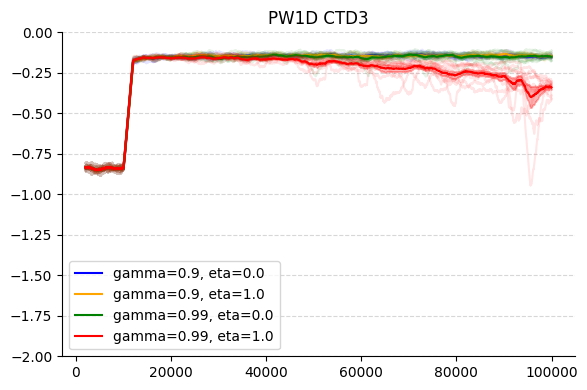

In [23]:
filenames = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscTD3_0.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscTD3_2.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscTD3_4.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscTD3_6.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-2,0.0),
                    title=r'PW1D CTD3', labels='gamma,eta')

Filename	eta	gamma	Value

SAC_14.	1.0	1.0	-0.384	0.011
SAC_11.	4.0	0.999	-0.532	0.008
cSAC_2.	1.0	0.9	-0.209	0.001
cSAC_0.	0.0	0.9	-0.206	0.001
cSAC_6.	1.0	0.99	-0.320	0.008
cSAC_5.	0.4	0.99	-0.248	0.003
SAC_13.	0.4	1.0	-0.326	0.008
SAC_10.	1.0	0.999	-0.385	0.009
cSAC_8.	0.0	0.999	-0.229	0.004
SAC_12.	0.0	1.0	-0.239	0.004
cSAC_7.	4.0	0.99	-0.470	0.008
cSAC_3.	4.0	0.9	-0.213	0.002
cSAC_9.	0.4	0.999	-0.307	0.008
cSAC_1.	0.4	0.9	-0.208	0.002
cSAC_4.	0.0	0.99	-0.224	0.003
SAC_15.	4.0	1.0	-0.543	0.009
0 0.0
1 0.4
2 1.0
3 4.0


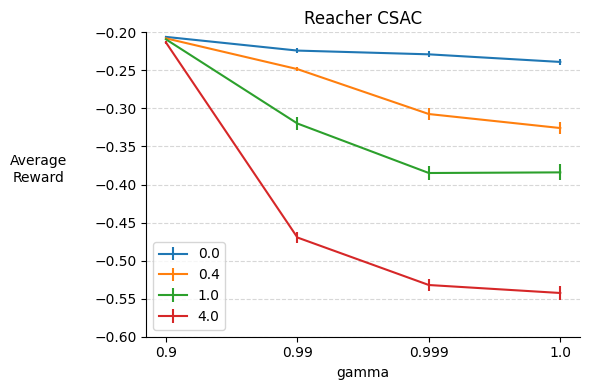

In [18]:
param_list = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscSAC', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-0.6, -0.2), #firstn=400, #logbase=10, 
                 title=r'Reacher CSAC', final=False)

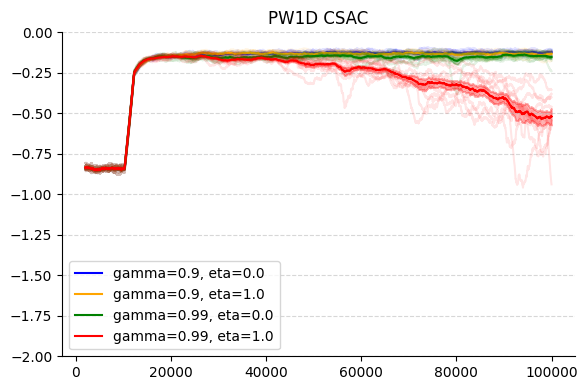

In [24]:
filenames = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscSAC_0.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscSAC_2.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscSAC_4.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscSAC_6.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-2,0.0),
                    title=r'PW1D CSAC', labels='gamma,eta')

Filename	eta	gamma	Value

4x64_9.	0.4	0.999	-0.368	0.003
x64_14.	1.0	1.0	-0.367	0.002
4x64_8.	0.0	0.999	-0.376	0.004
x64_10.	1.0	0.999	-0.366	0.003
x64_15.	4.0	1.0	-0.366	0.002
4x64_2.	1.0	0.9	-0.362	0.001
x64_11.	4.0	0.999	-0.365	0.003
4x64_1.	0.4	0.9	-0.363	0.001
4x64_4.	0.0	0.99	-0.362	0.002
x64_13.	0.4	1.0	-0.367	0.003
4x64_7.	4.0	0.99	-0.361	0.002
4x64_6.	1.0	0.99	-0.362	0.002
4x64_3.	4.0	0.9	-0.363	0.001
4x64_5.	0.4	0.99	-0.362	0.002
4x64_0.	0.0	0.9	-0.362	0.001
x64_12.	0.0	1.0	-0.381	0.006
0 0.0
1 0.4
2 1.0
3 4.0


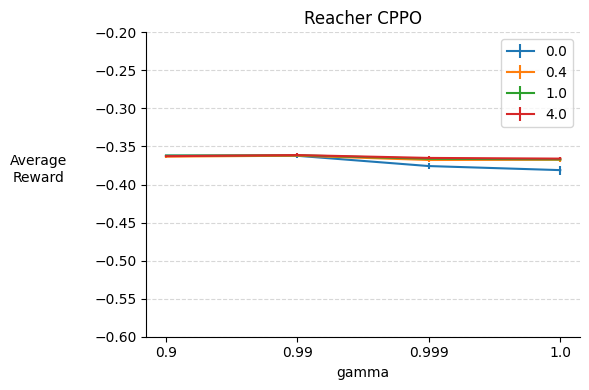

In [25]:
param_list = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscPPO', 'eta'),]

plot_sensitivity(param_list, 'reward', param2='gamma', ylabel='Average\nReward', param_choose_only=("critic_step_size", 0.001),
                 y_lims=(-0.6, -0.2), #firstn=400, #logbase=10, 
                 title=r'Reacher CPPO', final=False)

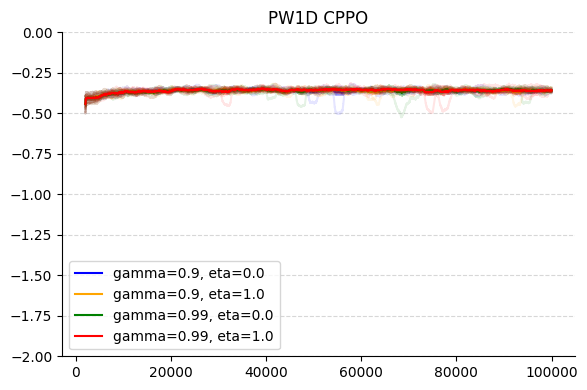

In [29]:
filenames = [('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscPPO_64x64_0.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscPPO_64x64_2.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscPPO_64x64_4.npy', ''),
             ('../results/centering_sweep_4/reacher/', 'reacher_cont_CDiscPPO_64x64_6.npy', ''),
            ]
plot_learning_curve(filenames, item='reward', window=2000, final=False, plot_all_runs=True, ylims=(-2,0.0),
                    title=r'PW1D CPPO', labels='gamma,eta')